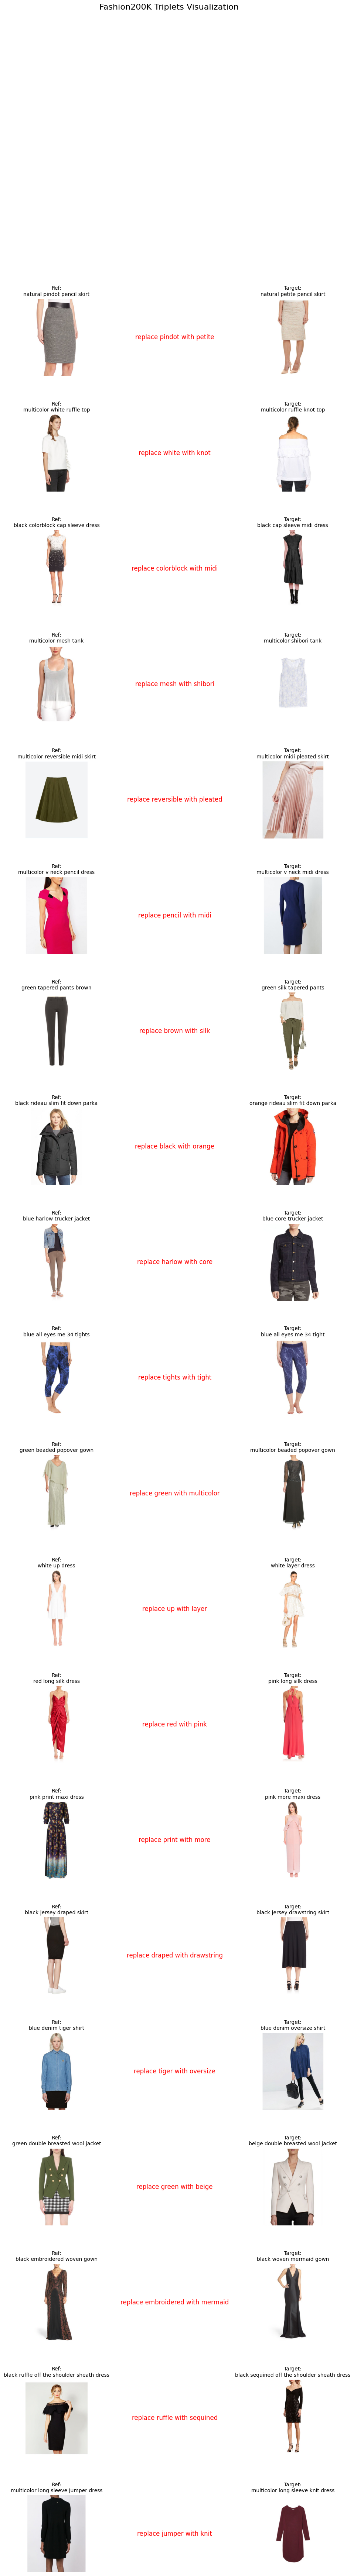

In [1]:
# File: visualize_triplets_grid_enhanced.ipynb

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random

# -----------------------------
# Config
# -----------------------------
triplets_file = "../data/processed/train_triplets.csv"  # CSV مع الأعمدة: ref_image, ref_caption, mod_text, target_image, target_caption
images_base_dir = "../data/raw/images"
num_samples = 20  # عدد الأمثلة التي تريد عرضها
grid_cols = 1  # عدد الصفوف = num_samples، أعمدة لكل triplet = 3 (ref | mod_text | target)
random_seed = 42

# -----------------------------
# Load triplets
# -----------------------------
df_triplets = pd.read_csv(triplets_file)
samples = df_triplets.sample(num_samples, random_state=random_seed).reset_index(drop=True)

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
fig.subplots_adjust(hspace=0.5, wspace=0.1)

for i, row in samples.iterrows():
    # Paths
    ref_path = os.path.join(images_base_dir, row["ref_path"])
    trg_path = os.path.join(images_base_dir, row["trg_path"])

    # Captions
    ref_caption = row.get("ref_caption", "")
    trg_caption = row.get("trg_caption", "")
    mod_text = row["mod_text"]

    # Load images
    ref_img = Image.open(ref_path)
    trg_img = Image.open(trg_path)

    # Reference image
    axes[i,0].imshow(ref_img)
    axes[i,0].set_title(f"Ref:\n{ref_caption}", fontsize=10)
    axes[i,0].axis("off")
    # Add border
    for spine in axes[i,0].spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(2)

    # Modification text
    axes[i,1].text(0.5, 0.5, mod_text, ha='center', va='center', fontsize=12, color='red', wrap=True)
    axes[i,1].axis("off")

    # Target image
    axes[i,2].imshow(trg_img)
    axes[i,2].set_title(f"Target:\n{trg_caption}", fontsize=10)
    axes[i,2].axis("off")
    for spine in axes[i,2].spines.values():
        spine.set_edgecolor('green')
        spine.set_linewidth(2)

plt.suptitle("Fashion200K Triplets Visualization", fontsize=16)
plt.show()
